In [2]:
import os
import numpy as np
import pandas as pd
import math
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import itertools
import random
import matplotlib.pyplot as plt
import seaborn as sns

import random
random.seed(42)
np.random.seed(42)

In [49]:
BASE_DIR = "/projects/standard/kumarv/shared/daycent/new_data"
INPUT_DIR = os.path.join(BASE_DIR, "inputs")
INVERSE_DIR = os.path.join(BASE_DIR, "inverse")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
POINTS_LOOKUP = os.path.join(BASE_DIR, "inputs/Midwest_lookupTable.xlsx")

PROCESSED_DIR = "/projects/standard/kumarv/shared/daycent/new_data/eda"

WEATHER_DIR = os.path.join(INPUT_DIR, "Weather")
INITC_FN = os.path.join(INPUT_DIR, "initial_site_conditions.xlsx")

HARVEST_FN = os.path.join(OUTPUT_DIR, "batch_001_010/scenario_1/SAS_scenario_1_harvest.csv")

SCENARIOS_FN = os.path.join(INPUT_DIR, "schedule_management_history_scen1_200.csv")

EXPERIMENT_NUMBER = 1

In [4]:
len(os.listdir(WEATHER_DIR))

9755

# EDA

In [5]:
df = pd.read_excel(POINTS_LOOKUP)

# # Calculate medians for splitting
# median_x = df['POINT_X'].median()
# median_y = df['POINT_Y'].median()

# # Create quadrants
# df['quadrant'] = 'Q1'
# df.loc[(df['POINT_X'] <= median_x) & (df['POINT_Y'] <= median_y), 'quadrant'] = 'Q1 (SW)'
# df.loc[(df['POINT_X'] > median_x) & (df['POINT_Y'] <= median_y), 'quadrant'] = 'Q2 (SE)'
# df.loc[(df['POINT_X'] <= median_x) & (df['POINT_Y'] > median_y), 'quadrant'] = 'Q3 (NW)'
# df.loc[(df['POINT_X'] > median_x) & (df['POINT_Y'] > median_y), 'quadrant'] = 'Q4 (NE)'

# # Method 1: Left/Right split for train-test
# left_half = df[df['POINT_X'] <= median_x]
# right_half = df[df['POINT_X'] > median_x]

# # Visualization
# fig = plt.figure(figsize=(18, 6))

# # Plot 1: Left/Right Train-Test Split
# ax1 = plt.subplot(131)
# ax1.scatter(left_half['POINT_X'], left_half['POINT_Y'], 
#            c='blue', s=100, alpha=0.6, label='Train (Left)', edgecolors='black')
# ax1.scatter(right_half['POINT_X'], right_half['POINT_Y'], 
#            c='red', s=100, alpha=0.6, label='Test (Right)', edgecolors='black')
# ax1.axvline(median_x, color='green', linestyle='--', linewidth=2, label='Split line')
# ax1.set_xlabel('Longitude (POINT_X)', fontsize=12)
# ax1.set_ylabel('Latitude (POINT_Y)', fontsize=12)
# ax1.set_title('Alternative Left/Right Train-Test Split', fontsize=14, fontweight='bold')
# ax1.legend()
# ax1.grid(True, alpha=0.3)

# # Plot 2: Quadrant Visualization
# ax2 = plt.subplot(132)
# colors = {'Q1 (SW)': '#FF6B6B', 'Q2 (SE)': '#4ECDC4', 'Q3 (NW)': '#45B7D1', 'Q4 (NE)': '#FFA07A'}
# for quadrant, color in colors.items():
#     mask = df['quadrant'] == quadrant
#     ax2.scatter(df.loc[mask, 'POINT_X'], df.loc[mask, 'POINT_Y'], 
#                c=color, s=120, alpha=0.7, label=quadrant, edgecolors='black', linewidth=1.5)

# # Add quadrant dividing lines
# ax2.axvline(median_x, color='black', linestyle='--', linewidth=2, alpha=0.7)
# ax2.axhline(median_y, color='black', linestyle='--', linewidth=2, alpha=0.7)

# # Add quadrant labels in the center of each quadrant
# x_min, x_max = df['POINT_X'].min(), df['POINT_X'].max()
# y_min, y_max = df['POINT_Y'].min(), df['POINT_Y'].max()
# ax2.text(median_x - (median_x - x_min)/2, median_y - (median_y - y_min)/2, 
#          'Q1', fontsize=20, ha='center', va='center', alpha=0.3, fontweight='bold')
# ax2.text(median_x + (x_max - median_x)/2, median_y - (median_y - y_min)/2, 
#          'Q2', fontsize=20, ha='center', va='center', alpha=0.3, fontweight='bold')
# ax2.text(median_x - (median_x - x_min)/2, median_y + (y_max - median_y)/2, 
#          'Q3', fontsize=20, ha='center', va='center', alpha=0.3, fontweight='bold')
# ax2.text(median_x + (x_max - median_x)/2, median_y + (y_max - median_y)/2, 
#          'Q4', fontsize=20, ha='center', va='center', alpha=0.3, fontweight='bold')

# ax2.set_xlabel('Longitude (POINT_X)', fontsize=12)
# ax2.set_ylabel('Latitude (POINT_Y)', fontsize=12)
# ax2.set_title('Quadrant Distribution', fontsize=14, fontweight='bold')
# ax2.legend(loc='best')
# ax2.grid(True, alpha=0.3)

# # Plot 3: Elevation by Quadrant
# ax3 = plt.subplot(133)
# scatter = ax3.scatter(df['POINT_X'], df['POINT_Y'], 
#                      c=df['elevation'], s=150, cmap='viridis', 
#                      alpha=0.7, edgecolors='black', linewidth=1.5)
# ax3.axvline(median_x, color='white', linestyle='--', linewidth=2, alpha=0.5)
# ax3.axhline(median_y, color='white', linestyle='--', linewidth=2, alpha=0.5)
# ax3.set_xlabel('Longitude (POINT_X)', fontsize=12)
# ax3.set_ylabel('Latitude (POINT_Y)', fontsize=12)
# ax3.set_title('Elevation with Quadrants', fontsize=14, fontweight='bold')
# cbar = plt.colorbar(scatter, ax=ax3)
# cbar.set_label('Elevation (m)', fontsize=11)
# ax3.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Print split information
# print("="*60)
# print("SPATIAL SPLIT SUMMARY")
# print("="*60)
# print(f"\nTotal points: {len(df)}")
# print(f"Split boundary X (Longitude): {median_x:.6f}")
# print(f"Split boundary Y (Latitude): {median_y:.6f}")

# print("\n--- LEFT/RIGHT SPLIT ---")
# print(f"Training points (Left): {len(left_half)} ({len(left_half)/len(df)*100:.1f}%)")
# print(f"Testing points (Right): {len(right_half)} ({len(right_half)/len(df)*100:.1f}%)")

# print("\n--- QUADRANT DISTRIBUTION ---")
# quadrant_counts = df['quadrant'].value_counts().sort_index()
# for quad, count in quadrant_counts.items():
#     print(f"{quad}: {count} points ({count/len(df)*100:.1f}%)")

# print("\n--- ELEVATION STATISTICS BY QUADRANT ---")
# for quad in sorted(df['quadrant'].unique()):
#     quad_data = df[df['quadrant'] == quad]['elevation']
#     print(f"{quad}: Mean={quad_data.mean():.2f}m, Min={quad_data.min():.2f}m, Max={quad_data.max():.2f}m")

# # Example: Use alternating quadrants for train/test
# print("\n" + "="*60)
# print("ALTERNATIVE: CHECKERBOARD TRAIN-TEST SPLIT")
# print("="*60)
# train_quadrants = ['Q1 (SW)']
# test_quadrants = ['Q4 (NE)']
# train_checker = df[df['quadrant'].isin(train_quadrants)]
# test_checker = df[df['quadrant'].isin(test_quadrants)]
# print(f"Train (Q1): {len(train_checker)} points")
# print(f"Test (Q4): {len(test_checker)} points")

### Inverse Modelling

In [6]:
random.seed(42)
np.random.seed(42)
str_points = df['id'].astype(str).tolist()
str_points = random.sample(str_points, 500)
train_points = str_points[:400]
test_points = str_points[400:]
print(str_points)

['449076', '173488', '729873', '703436', '653239', '519996', '422587', '1719902', '374802', '1783162', '848743', '217678', '205830', '389437', '646080', '674884', '1710249', '186702', '1724327', '617594', '1719763', '848369', '648892', '1234556', '1778709', '732613', '32556', '553115', '849768', '784957', '732407', '547609', '641536', '783283', '421670', '386113', '805271', '398888', '794704', '786726', '720684', '270212', '1276706', '1717164', '481570', '804540', '361676', '1721980', '738796', '796208', '1740307', '607785', '323194', '274861', '662804', '737592', '363407', '675324', '416811', '805418', '732499', '1251789', '798004', '557467', '800603', '792868', '631989', '723163', '325235', '567681', '1717083', '703198', '558877', '1277292', '805055', '724847', '1723334', '647676', '781045', '301454', '664763', '219831', '778095', '829677', '723859', '319737', '634649', '1729567', '776552', '636911', '1708977', '819474', '1275345', '527357', '720981', '520059', '705403', '1724353', '

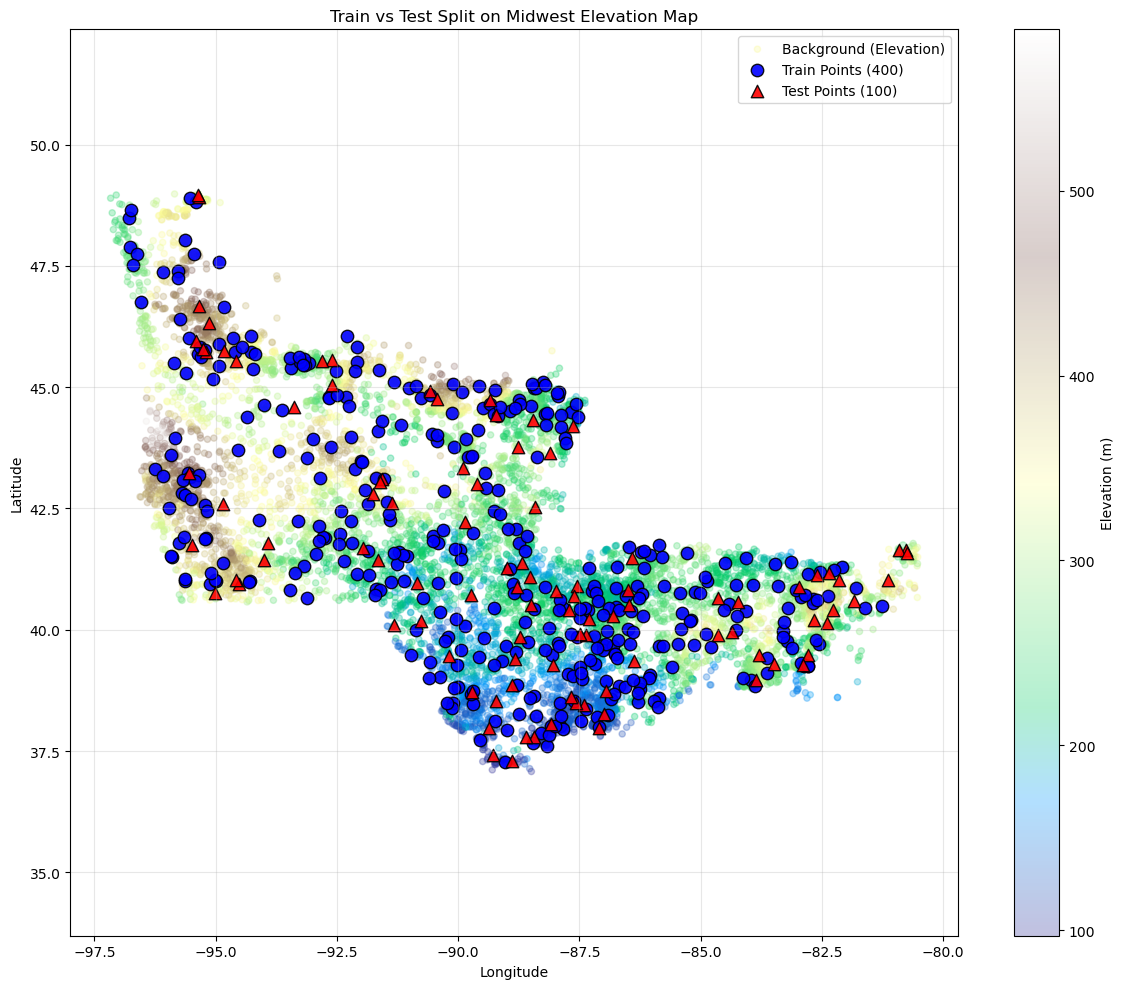

In [7]:
# plot the following train and test points on a map of the midwest. Use different colors for train and test. Also plot the elevation as a color gradient. Add a legend and title to the plot.

# # expt 1 points
# train_points = ['1208427', '643429', '168881', '662372', '283990', '1727802', '711604', '328178', '527894', '672990', '561897', '624035', '437720', '610911', '793034', '1707482', '785622', '847626', '469559', '1722014', '793734', '1718241', '851763', '1278849', '220410', '623452', '737680', '848312', '793629', '559057', '762518', '719498', '1722709', '789391', '828011', '797014', '795151', '1700521', '1700246', '1738309', '851766', '851756', '851593', '1721997', '699752', '1265616', '1720133', '781881', '315457', '807335', '756689', '783078', '1203588', '692512', '679724', '644580', '367609', '782066', '822984', '1716441', '363289', '847876', '783983', '1708937', '614007', '1227635', '782648', '847939', '847864', '833133', '537511', '1699345', '1717037', '214556', '709686', '1711752', '567807', '851408',]
# test_points  = ['395207', '606561', '771165', '208915', '1743748', '738640', '615916', '317701', '786271', '672412', '819858', '1731910', '645475', '979981', '263932', '443937', '320088', '281642', '1715892', '979852', '589052', '728475']

def plot_train_test_points(df, train_points, test_points):

    # Filter for train/test data
    train_df = df[df['id'].astype(str).isin(train_points)]
    test_df = df[df['id'].astype(str).isin(test_points)]
    
    plt.figure(figsize=(12, 10))

    # # 1. Plot background (Elevation)
    # We plot all points to show the map context and elevation gradient
    scatter = plt.scatter(df['POINT_X'], df['POINT_Y'], 
                          c=df['elevation'], cmap='terrain', alpha=0.3, s=20, label='Background (Elevation)')
    
    # Add colorbar for elevation
    cbar = plt.colorbar(scatter)
    cbar.set_label('Elevation (m)')

    # 2. Plot Train points
    plt.scatter(train_df['POINT_X'], train_df['POINT_Y'], 
                c='blue', s=80, marker='o', edgecolors='black', label=f'Train Points ({len(train_df)})', alpha=0.9)
    
    # 3. Plot Test points
    plt.scatter(test_df['POINT_X'], test_df['POINT_Y'], 
                c='red', s=80, marker='^', edgecolors='black', label=f'Test Points ({len(test_df)})', alpha=0.9)

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Train vs Test Split on Midwest Elevation Map')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Optional: Set aspect ratio to be equal so the map doesn't look distorted
    plt.axis('equal')
    
    plt.tight_layout()
    plt.show()

plot_train_test_points(df, train_points, test_points)

In [8]:
df = pd.read_csv("/projects/standard/kumarv/shared/daycent/new_data/inputs/schedule_management_history_scen1_200.csv")

In [9]:
df


,scenario,id,STATE,simyear,doy,management
0,scenario_1,73732,IA,2000,136,conventional_till_molboadplow
1,scenario_1,73732,IA,2000,140,herbicide
2,scenario_1,73732,IA,2000,141,soybean_planting
3,scenario_1,73732,IA,2000,141,nitrogen_fertilization_1.6gNm2
4,scenario_1,73732,IA,2000,283,harvest_grain
...,...,...,...,...,...,...
299291597,scenario_99,1745165,WI,2022,315,winterwheat_planting
299291598,scenario_99,1745165,WI,2022,315,nitrogen_fertilization_10.48gNm2
299291599,scenario_99,1745165,WI,2023,212,harvest_grain
299291600,scenario_99,1745165,WI,2023,212,cycle_end


In [10]:
mask = df['id'].astype(str).isin(str_points) & df['scenario'].astype(str).isin([f'scenario_{i}' for i in range(1, 31)])
scenarios_df = df[mask]

In [11]:
import re

def consolidate_management_labels(val):
    # If it's not a nitrogen column, leave it alone (e.g. 'corn_planting')
    if 'nitrogen_fertilization' not in val:
        return val

    # Regex to extract the floating point number from the string
    # Looks for digits/decimals inside the string
    match = re.search(r'(\d+\.?\d*)', val)
    if not match:
        return val # Fallback if something weird happens
        
    num = float(match.group(1))

    # 2. Inequality Grouping (Binning)
    # These cutoffs are based on the data spread you provided.
    
    # CASE: 0 (or very close to it)
    if num < 0.5:
        return 'nitrogen_fertilization_0gNm2'
    
    # CASE: ~1.5 (covers 1.45, 1.9, 2.6)
    # Everything between 0.5 and 5.0 gets mapped to the old "1.5" label
    elif num < 5.0:
        return 'nitrogen_fertilization_1.5gNm2'
    
    # CASE: ~10.3 (covers 10.29, 10.8, 12.4, 14.6)
    # Everything between 5.0 and 15.5 gets mapped to the old "10.312" label
    elif num < 15.5:
        return 'nitrogen_fertilization_10.312gNm2'
    
    # CASE: ~17.7 (covers 16.9, 17.75)
    # Everything above 15.5 gets mapped to the old "17.74" label
    else:
        return 'nitrogen_fertilization_17.74gNm2'

# 3. Apply this to your dataframe BEFORE pivoting
scenarios_df['management'] = scenarios_df['management'].apply(consolidate_management_labels)

In [12]:
scenarios_df = scenarios_df.rename({'simyear': 'Year'}, axis=1)
scenarios_df

,scenario,id,STATE,Year,doy,management
1265,scenario_1,93550,IA,2000,136,conventional_till_molboadplow
1266,scenario_1,93550,IA,2000,140,herbicide
1267,scenario_1,93550,IA,2000,141,soybean_planting
1268,scenario_1,93550,IA,2000,141,nitrogen_fertilization_1.5gNm2
1269,scenario_1,93550,IA,2000,283,harvest_grain
...,...,...,...,...,...,...
285261647,scenario_9,1743748,WI,2022,315,winterwheat_planting
285261648,scenario_9,1743748,WI,2022,315,nitrogen_fertilization_10.312gNm2
285261649,scenario_9,1743748,WI,2023,212,harvest_grain
285261650,scenario_9,1743748,WI,2023,212,cycle_end


In [13]:
scenarios_df['scenario_id'] = scenarios_df['scenario'].str.replace('scenario_', '')

In [14]:
scenarios_df = scenarios_df.pivot_table(
    index=['scenario_id', 'id', 'Year', 'doy'],
    columns='management',
    aggfunc='size',
    fill_value=0
).reset_index()

In [15]:
scenarios_df['id'].nunique()

500

In [16]:
scenarios_df

management,scenario_id,id,Year,doy,conventional_till_molboadplow,corn_planting,cycle_end,harvest_grain,herbicide,nitrogen_fertilization_0gNm2,nitrogen_fertilization_1.5gNm2,nitrogen_fertilization_10.312gNm2,nitrogen_fertilization_17.74gNm2,notill_rodweederrow,reduced_till_tandemdisk,ryegrass_planting,soybean_planting,winterwheat_planting
0,1,5679,2000,136,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,5679,2000,140,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,1,5679,2000,141,0,0,0,0,0,0,1,0,0,0,0,0,1,0
3,1,5679,2000,282,0,0,1,1,0,0,0,0,0,0,0,0,0,0
4,1,5679,2000,287,1,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579100,9,1798896,2022,289,0,0,1,1,0,0,0,0,0,0,0,0,0,0
1579101,9,1798896,2022,294,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1579102,9,1798896,2022,315,0,0,0,0,0,0,0,1,0,0,0,0,0,1
1579103,9,1798896,2023,200,0,0,1,1,0,0,0,0,0,0,0,0,0,0


In [ ]:
scenarios_df.to_csv(os.path.join(INVERSE_DIR, f"management_scenario_{EXPERIMENT_NUMBER}.csv"), index=False)

In [20]:
scenarios_df.keys()

Index(['scenario_id', 'id', 'Year', 'doy', 'conventional_till_molboadplow',
       'corn_planting', 'cycle_end', 'harvest_grain', 'herbicide',
       'nitrogen_fertilization_0gNm2', 'nitrogen_fertilization_1.5gNm2',
       'nitrogen_fertilization_10.312gNm2', 'nitrogen_fertilization_17.74gNm2',
       'notill_rodweederrow', 'reduced_till_tandemdisk', 'ryegrass_planting',
       'soybean_planting', 'winterwheat_planting'],
      dtype='object', name='management')

# Daily drivers

In [21]:
path = "/projects/standard/kumarv/shared/daycent/new_data/outputs/scenario_1/SAS_scenario_1_daily_part2.csv"

df = pd.read_csv(path)

In [22]:
df.keys()

Index(['runid', 'id', 'simyear', 'dayofyr', 'trandly_mm', 'evapdly_mm',
       'CO2resp', 'NPP', 'NEE', 'N2O_N_gm2', 'vwc_10', 'gresp', 'mresp',
       'Reco', 'GPP'],
      dtype='object')

In [23]:
df

,runid,id,simyear,dayofyr,trandly_mm,evapdly_mm,CO2resp,NPP,NEE,N2O_N_gm2,vwc_10,gresp,mresp,Reco,GPP
0,1655,411121,2000,1,0.000,0.000,0.7117,0.0000,-0.7117,0.000057,0.434567,0.0000,0.0000,0.7117,0.0000
1,1655,411121,2000,2,0.000,0.000,0.6624,0.0000,-0.6624,0.000052,0.436900,0.0000,0.0000,0.6624,0.0000
2,1655,411121,2000,3,0.000,0.000,0.6272,0.0000,-0.6272,0.000051,0.435967,0.0000,0.0000,0.6272,0.0000
3,1655,411121,2000,4,0.000,0.000,0.5929,0.0000,-0.5929,0.000050,0.435067,0.0000,0.0000,0.5929,0.0000
4,1655,411121,2000,5,0.000,0.000,0.5658,0.0000,-0.5658,0.000037,0.434133,0.0000,0.0000,0.5658,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14481427,3309,618884,2023,361,0.094,0.115,0.9206,0.1212,-0.7994,0.000215,0.309533,0.0279,0.0102,0.9587,0.1593
14481428,3309,618884,2023,362,0.093,0.112,0.8973,0.0596,-0.8376,0.000223,0.309567,0.0137,0.0085,0.9195,0.0818
14481429,3309,618884,2023,363,0.094,0.114,0.8785,0.0549,-0.8236,0.000238,0.470867,0.0126,0.0085,0.8996,0.0760
14481430,3309,618884,2023,364,0.093,0.181,0.8329,0.0000,-0.8329,0.000232,0.467533,0.0000,0.0073,0.8402,0.0073


In [28]:
os.path.join(OUTPUT_DIR, f"scenario_1", "*daily*.csv")

'/projects/standard/kumarv/shared/daycent/new_data/outputs/scenario_1/*daily*.csv'

In [29]:
import glob
glob.glob(os.path.join(OUTPUT_DIR, f"scenario_1", "*daily*.csv"))

['/projects/standard/kumarv/shared/daycent/new_data/outputs/scenario_1/SAS_scenario_1_daily_part1.csv',
 '/projects/standard/kumarv/shared/daycent/new_data/outputs/scenario_1/SAS_scenario_1_daily_part2.csv',
 '/projects/standard/kumarv/shared/daycent/new_data/outputs/scenario_1/SAS_scenario_1_daily_part3.csv',
 '/projects/standard/kumarv/shared/daycent/new_data/outputs/scenario_1/SAS_scenario_1_daily_part4.csv',
 '/projects/standard/kumarv/shared/daycent/new_data/outputs/scenario_1/SAS_scenario_1_daily_part5.csv',
 '/projects/standard/kumarv/shared/daycent/new_data/outputs/scenario_1/SAS_scenario_1_daily_part6.csv']

In [ ]:
import glob
# for all scenarios 1-20, get all daily csv files which are in parts. concat them and filter for str_points. save the consolidated csv files for each scenario in the processed dir.
dfs = []
for scenario in range(1, 2):
    daily_files = glob.glob(os.path.join(OUTPUT_DIR, f"scenario_{scenario}", "*daily*.csv"))
    
    for file in daily_files:
        df = pd.read_csv(file)
        filtered = df[df['id'].astype(str).isin(str_points)]
        dfs.append(filtered)

consolidated = pd.concat(dfs, ignore_index=True)

In [ ]:
important_keys = ["trandly_mm", "evapdly_mm", "CO2resp", "NPP", "GPP", "vwc_10", "N2O_N_gm2"]
consolidated.rename(columns = {"simyear": "Year", "dayofyr": "doy"}, inplace=True)
consolidated = consolidated[["id", "Year", "doy"] + important_keys]

In [38]:
consolidated

,id,Year,doy,trandly_mm,evapdly_mm,CO2resp,NPP,GPP,vwc_10,N2O_N_gm2
0,5679,2000,1,0.000,0.000,0.5869,0.0000,0.0519,0.185033,0.000057
1,5679,2000,2,0.000,0.000,0.5504,0.0000,0.0534,0.185300,0.000049
2,5679,2000,3,0.000,0.000,0.5277,0.0000,0.0615,0.185533,0.000045
3,5679,2000,4,0.000,0.000,0.5072,0.0000,0.0298,0.185800,0.000041
4,5679,2000,5,0.000,0.000,0.4905,0.0000,0.0260,0.186033,0.000039
...,...,...,...,...,...,...,...,...,...,...
4382995,1798896,2023,361,0.177,0.175,0.8107,0.2418,0.3113,0.278400,0.000096
4382996,1798896,2023,362,0.132,0.129,0.7633,0.0774,0.1060,0.279167,0.000097
4382997,1798896,2023,363,0.151,0.148,0.7574,0.0791,0.1080,0.278833,0.000087
4382998,1798896,2023,364,0.169,0.282,0.7226,0.0809,0.1099,0.274467,0.000090


### Weather analysis

In [40]:
all_points = []

for points in str_points:
    df = pd.read_csv(os.path.join(WEATHER_DIR, points + ".csv"))
    df['point_id'] = points.split(".csv")[0]
    all_points.append(df)

weather_df = pd.concat(all_points, ignore_index=True)
weather_df

,Year,DOY,Tmax,Tmin,Precip,point_id
0,2000,1,8.940,-5.140,0.000,449076
1,2000,2,13.390,0.580,0.000,449076
2,2000,3,16.350,1.970,0.015,449076
3,2000,4,11.020,-1.860,1.963,449076
4,2000,5,-1.190,-7.250,0.000,449076
...,...,...,...,...,...,...
4565995,2024,362,1.661,-4.700,0.000,573274
4565996,2024,363,7.304,-5.081,0.000,573274
4565997,2024,364,7.187,-2.106,0.000,573274
4565998,2024,365,5.331,-6.987,0.000,573274


In [47]:
weather_df["point_id"] = weather_df["point_id"].astype(str)
consolidated["id"] = consolidated["id"].astype(str)
weather_df["point_id"].nunique(), consolidated["id"].nunique()

(500, 500)

In [51]:
merged = pd.merge(weather_df, consolidated, left_on=["point_id", "Year", "DOY"], right_on=["id", "Year", "doy"], how="inner")
merged = merged.drop(columns=["id", "doy"])
merged

,Year,DOY,Tmax,Tmin,Precip,point_id,trandly_mm,evapdly_mm,CO2resp,NPP,GPP,vwc_10,N2O_N_gm2
0,2000,1,8.94,-5.14,0.000,449076,0.0,0.0,0.7042,0.0,0.0000,0.382967,0.000059
1,2000,2,13.39,0.58,0.000,449076,0.0,0.0,0.6439,0.0,0.0000,0.462167,0.000051
2,2000,3,16.35,1.97,0.015,449076,0.0,0.0,0.6042,0.0,0.0000,0.490967,0.000085
3,2000,4,11.02,-1.86,1.963,449076,0.0,0.0,0.8591,0.0,0.0000,0.490800,0.000079
4,2000,5,-1.19,-7.25,0.000,449076,0.0,0.0,0.5493,0.0,0.0000,0.490633,0.000075
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4382995,2023,361,2.26,-4.09,0.000,573274,0.0,0.0,0.7682,0.0,0.0062,0.310000,0.000193
4382996,2023,362,-2.82,-8.17,0.372,573274,0.0,0.0,0.7555,0.0,0.0047,0.310167,0.000189
4382997,2023,363,-3.32,-7.25,0.716,573274,0.0,0.0,0.7596,0.0,0.0049,0.310333,0.000185
4382998,2023,364,-3.43,-8.18,0.170,573274,0.0,0.0,0.7357,0.0,0.0046,0.310500,0.000184


In [52]:
merged.to_csv(os.path.join(INVERSE_DIR, f"merged_weather_response_{EXPERIMENT_NUMBER}.csv"), index=False)

In [57]:
# all keys except Year, DOY, point_id
merged[merged.columns.difference(['point_id', 'Year', 'DOY'])]

,CO2resp,GPP,N2O_N_gm2,NPP,Precip,Tmax,Tmin,evapdly_mm,trandly_mm,vwc_10
0,0.7042,0.0000,0.000059,0.0,0.000,8.94,-5.14,0.0,0.0,0.382967
1,0.6439,0.0000,0.000051,0.0,0.000,13.39,0.58,0.0,0.0,0.462167
2,0.6042,0.0000,0.000085,0.0,0.015,16.35,1.97,0.0,0.0,0.490967
3,0.8591,0.0000,0.000079,0.0,1.963,11.02,-1.86,0.0,0.0,0.490800
4,0.5493,0.0000,0.000075,0.0,0.000,-1.19,-7.25,0.0,0.0,0.490633
...,...,...,...,...,...,...,...,...,...,...
4382995,0.7682,0.0062,0.000193,0.0,0.000,2.26,-4.09,0.0,0.0,0.310000
4382996,0.7555,0.0047,0.000189,0.0,0.372,-2.82,-8.17,0.0,0.0,0.310167
4382997,0.7596,0.0049,0.000185,0.0,0.716,-3.32,-7.25,0.0,0.0,0.310333
4382998,0.7357,0.0046,0.000184,0.0,0.170,-3.43,-8.18,0.0,0.0,0.310500
